Canny Edge Detection

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [42]:
img = cv2.imread('image.webp', cv2.IMREAD_GRAYSCALE)

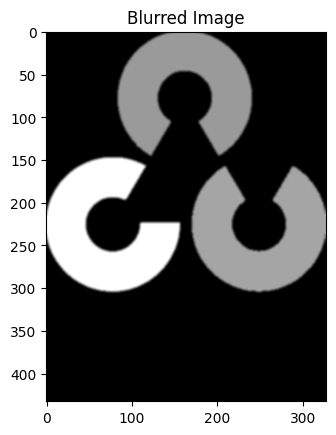

In [43]:
#Guassian Blur Formula = I * G
blur = cv2.GaussianBlur(img, (5, 5), 1.4)

plt.imshow(blur, cmap='gray')
plt.title('Blurred Image')
plt.show()

2 - Sobel Operator

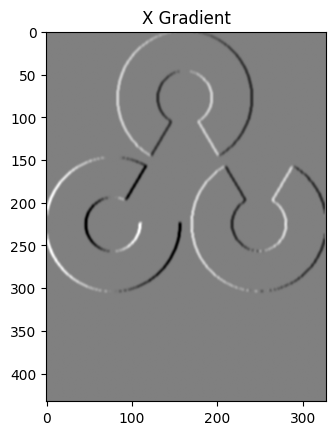

In [44]:
Gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)

plt.imshow(Gx, cmap='gray')
plt.title('X Gradient')
plt.show()

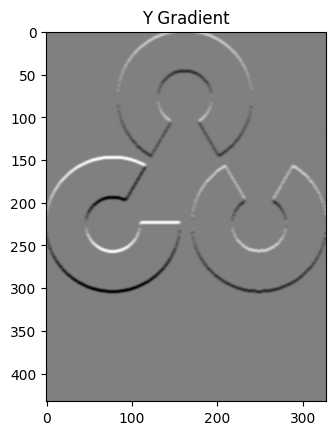

In [45]:
Gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)

plt.imshow(Gy, cmap='gray')
plt.title('Y Gradient')
plt.show()

Calc Magnitude

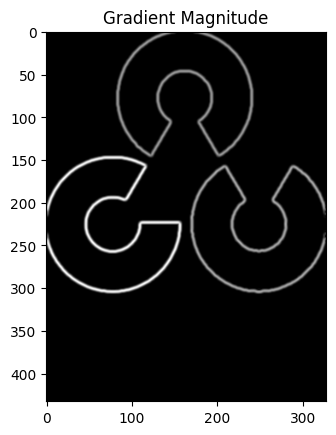

In [46]:
magnitude = np.sqrt(Gx**2 + Gy**2)

plt.imshow(magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.show()

Calc Theta

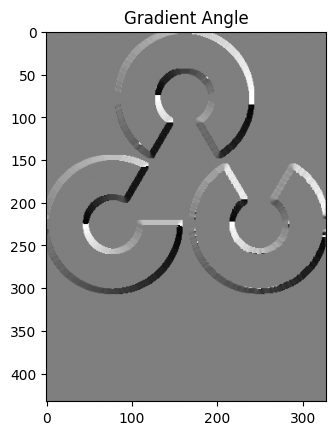

In [47]:
angle = np.arctan2(Gy, Gx)

plt.imshow(angle, cmap='gray')
plt.title('Gradient Angle')
plt.show()

Normalize Magnitude

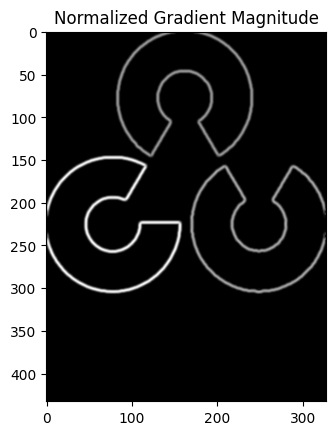

In [48]:
magnitude = (magnitude/magnitude.max()) * 255

plt.imshow(magnitude, cmap='gray')
plt.title('Normalized Gradient Magnitude')
plt.show()

Create NMS (non maximum suppression) function

In [49]:
def nms(magnitude, angle):
    H, W = magnitude.shape
    Z = np.zeros((H, W), dtype=np.float32)
    #Convert angle from radian to degree
    angle = angle * 180 / np.pi
    angle[angle < 0] += 180
    
    for i in range(1, H-1):
        for j in range(1, W-1):
            q = 255
            r = 255
            
            #at 0 degree
            if(0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = magnitude[i, j+1]
                r = magnitude[i, j-1]
            
            #at 45 degree
            elif(22.5 <= angle[i,j] < 67.5):
                q = magnitude[i+1, j-1]
                r = magnitude[i-1, j+1]
            
            #at 90 degree
            elif(67.5 <= angle[i,j] < 112.5):
                q = magnitude[i+1, j]
                r = magnitude[i-1, j]
            
            #at 135 degree
            elif(112.5 <= angle[i,j] < 157.5):                                      
                q = magnitude[i-1, j-1]
                r = magnitude[i+1, j+1]
            
            #suppression condition
            
            if(magnitude[i,j] >= q and magnitude[i,j] >= r):
                Z[i,j] = magnitude[i,j]
            else:
                Z[i,j] = 0
    return Z

Apply NMS

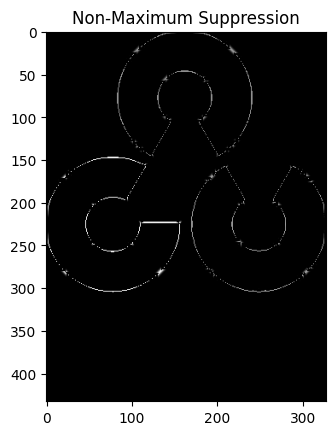

In [50]:
nms_op = nms(magnitude, angle)

plt.imshow(nms_op, cmap='gray')
plt.title('Non-Maximum Suppression')
plt.show()

Thresholding (basic)

In [51]:
strong = 100
weak = 50
res = np.zeros_like(nms_op)

high_thres = magnitude.max() * 0.2
low_thres = high_thres * 0.5

print(high_thres, low_thres)

51.0 25.5


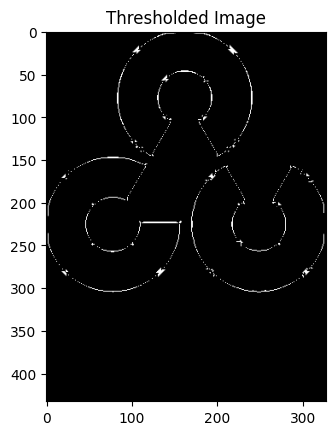

In [52]:
strong_i, strong_j = np.where(nms_op >= high_thres)
weak_i, weak_j = np.where((nms_op >= low_thres) & (nms_op <= high_thres))

res[strong_i, strong_j] = strong
res[weak_i, weak_j] = weak

plt.imshow(res, cmap='gray')
plt.title('Thresholded Image')
plt.show()

In [53]:
angle = np.arctan2(Gy, Gx)
print(angle.max())

3.141592653589793
